# Jumper Notebook: ConvVAE + GP Forecast Workflow

This notebook follows the refactored helper-based pipeline:
1. setup and parameters
2. load and prepare simulations
3. PCA decomposition and diagnostics
4. component-space forecasting
5. reconstruction and save
6. error evaluation
7. component-space comparison against a reference window


In [2]:
import sys
from pathlib import Path

# Print current working directory
print("Current Working Directory:", Path.cwd())

# Find the project root by searching upwards for 'src'
current = Path.cwd().resolve()
src_path = None

# Look for 'src' in current directory or parent directories
for p in [current] + list(current.parents):
    candidate = p / "src"
    if candidate.exists() and (candidate / "nemo_spinup_forecast").exists():
        src_path = candidate
        break

if src_path:
    print(f"Found package at: {src_path}")
    if str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))
    print("Added to sys.path successfully!")
else:
    print("Could not locate 'src/nemo_spinup_forecast'. Please check folder structure.")

Current Working Directory: c:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\Notebooks
Found package at: C:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\src
Added to sys.path successfully!


In [2]:
import sys
from pathlib import Path

repo = Path(r"C:/2025/MSc CS AI/Thesis/NEMO Spin-Up Benchmark/nemo-spinup-forecast").resolve()
src = repo / "src"

if str(src) not in sys.path:
    sys.path.insert(0, str(src))

%pip install -e "{repo}"

Obtaining file:///C:/2025/MSc%20CS%20AI/Thesis/NEMO%20Spin-Up%20Benchmark/nemo-spinup-forecast
  Installing build dependencies: started
  Installing build dependencies: still running...
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Using cached xarray-2026.7.0-py3-none-any.whl.metadata (12 kB)
  Using cached dask-2026.7.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached partd-1.4.2-py3-none-any.whl.metadata (4.6 kB)
  Using cached toolz-1.1.0-py3-none-any.whl.metadata (5.1 kB)
  Using cached locket-1.0.0-py2.py3-no


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:

import pickle
from importlib.resources import files
from pathlib import Path

import numpy as np
import pandas as pd

from nemo_spinup_forecast.dimensionality_reduction import (
    dimensionality_reduction_techniques,
)
from nemo_spinup_forecast.forecast_method import forecast_techniques
from nemo_spinup_forecast.pipeline_utils import (
    TermSpec,
    abs_error_stats,
    build_predictions,
    build_simulations,
    compute_rmse_for_terms,
    decompose_all,
    forecast_all,
    load_ts_all,
    make_dicos,
    normalise_time_series,
)
from nemo_spinup_forecast.plotting_utils import (
    plot_bar_with_errors,
    plot_component_timeseries,
    plot_depth_error_profiles,
    plot_depth_prediction_reference,
    plot_pca_diagnostics,
    plot_reconstructions,
    plot_rmse_depth_profile,
    plot_rmse_maps,
    plot_simulation_snapshots,
)
from nemo_spinup_forecast.utils import (
    create_run_dir,
    get_ocean_term,
)

c:\Users\yashodhara singh\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [77]:
import pickle
from importlib.resources import files
from pathlib import Path

import numpy as np
import pandas as pd

from nemo_spinup_forecast.dimensionality_reduction import (
    dimensionality_reduction_techniques,
)
from nemo_spinup_forecast.forecast_method import forecast_techniques
from nemo_spinup_forecast.pipeline_utils import (
    TermSpec,
    abs_error_stats,
    build_predictions,
    build_simulations,
    compute_rmse_for_terms,
    decompose_all,
    forecast_all,
    load_ts_all,
    make_dicos,
    normalise_time_series,
)

# Updated to import CVAE-compatible plotting utilities
from nemo_spinup_forecast.plotting_utils_cvae import (
    plot_bar_with_errors,
    plot_component_timeseries,
    plot_depth_error_profiles,
    plot_depth_prediction_reference,
    plot_dr_diagnostics,  # Replaced plot_pca_diagnostics
    plot_reconstructions,
    plot_rmse_depth_profile,
    plot_rmse_maps,
    plot_simulation_snapshots,
)
from nemo_spinup_forecast.utils import (
    create_run_dir,
    get_ocean_term,
)

## Parameters and Outputs

### Inputs and slicing
- `data_path`: root directory containing DINO simulation files.
- `ye`: yearly processing flag passed to `Simulation`.
- `start`, `end`: slice bounds for the training/reference window.
- `comp_value`: number of components used, or amount of variance kept, passed to dimensionality reduction.

### Forecast horizon
- `steps`: number of forecast time steps.

### Run-scoped outputs
- `run_dir`: timestamped path created by `create_run_dir(data_path)`.
- `out_dir`: `<run_dir>/forecasts`.
- `prepared_dir`: `<out_dir>/simu_prepared` — one subdirectory per term (e.g. `ssh/ssh.npz`, `ssh/pca_ssh`).
- `pred_dir`: `<out_dir>/simu_predicted` for reconstructed fields (`pred_*.npy`).

In [ ]:
data_path = str(Path("../tests/data/nemo_data_e3/").resolve())
run_dir = create_run_dir(str(data_path))
out_dir = Path(run_dir)
prepared_dir = out_dir / "simu_prepared"
pred_dir = out_dir / "simu_predicted"

ye = True

start = 10
end = 40
comp_value = 3  # number of components used, or amount of variance kept
steps = 10

In [44]:
data_path = str(Path(r"C:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\2026-07-15_22-52-04.093130Z_3eae7915\forecast").resolve())
run_dir = create_run_dir(str(data_path))
out_dir = Path(run_dir)
prepared_dir = out_dir / "simu_prepared"
pred_dir = out_dir / "simu_predicted"

ye = True

# Match CLI run parameters
ye = False        # Monthly timesteps
start = 0         # Starting month
end = 2400        # 200 years * 12 months
comp_value = 10   # 10 ConvVAE latent dimensions
steps = 1

## 1) Load and prepare simulations


This section resolves ocean-term names, defines `TERM_SPECS`, and calls
`build_simulations(...)`.

`build_simulations(...)` loads the `start:end` slice and standardizes it with
`(value - mean) / (2 * std)` before PCA.

`TERM_SPECS` also defines later reductions:
- `mean_axes` for mean profiles.
- `err_axes` for error summaries.

SSH (`zos`) has shape `(time, lat, lon)`, so reducing space gives a time series.
Salinity and temperature have shape `(time, depth, lat, lon)`, so reducing time and
horizontal axes gives a depth profile.


In [ ]:
# Load packaged ocean-term mapping.
ocean_terms_cfg = files("nemo_spinup_forecast.configs").joinpath("ocean_terms.DINO.yaml")

ssh_term = get_ocean_term("SSH", yaml_path=ocean_terms_cfg)
so_term = get_ocean_term("Salinity", yaml_path=ocean_terms_cfg)
thetao_term = get_ocean_term("Temperature", yaml_path=ocean_terms_cfg)

# Technique selection — change the dict key to swap technique
dimensionality_reduction_method = dimensionality_reduction_techniques["PCA"]
forecast_method = forecast_techniques["GaussianProcessForecaster"]

# `mean_axes` and `err_axes` depend on the field shape.
# SSH is stored as (time, lat, lon), so collapsing (lat, lon) leaves a time series.
# Salinity and temperature are stored as (time, depth, lat, lon), so collapsing
# (time, lat, lon) leaves a depth profile.
TERM_SPECS = [
    TermSpec(
        "zos",
        ssh_term,
        "DINO_1m_To_1y_grid_T.nc",
        mean_axes=(1, 2),  # reduce (lat, lon) -> time series
        err_axes=(0, 1, 2),  # reduce (time, lat, lon) -> scalar summary
    ),
    TermSpec(
        "so",
        so_term,
        "DINO_1y_grid_T.nc",
        mean_axes=(0, 2, 3),  # reduce (time, lat, lon) -> depth profile
        err_axes=(0, 2, 3),  # reduce (time, lat, lon) -> per-depth summary
    ),
    TermSpec(
        "thetao",
        thetao_term,
        "DINO_1y_grid_T.nc",
        mean_axes=(0, 2, 3),  # reduce (time, lat, lon) -> depth profile
        err_axes=(0, 2, 3),  # reduce (time, lat, lon) -> per-depth summary
    ),
]


sims = build_simulations(
    TERM_SPECS,
    data_path=data_path,
    start=start,
    end=end,
    comp=comp_value,
    ye=ye,
    dr_method=dimensionality_reduction_method,
    stand=True,
)

In [45]:
# Load packaged ocean-term mapping.
ocean_terms_cfg = files("nemo_spinup_forecast.configs").joinpath("ocean_terms.DINO.yaml")

ssh_term = get_ocean_term("SSH", yaml_path=ocean_terms_cfg)
so_term = get_ocean_term("Salinity", yaml_path=ocean_terms_cfg)
thetao_term = get_ocean_term("Temperature", yaml_path=ocean_terms_cfg)

# Technique selection — change the dict key to swap technique
dimensionality_reduction_method = dimensionality_reduction_techniques["cvae"]
forecast_method = forecast_techniques["GaussianProcessForecaster"]

# `mean_axes` and `err_axes` depend on the field shape.
# SSH is stored as (time, lat, lon), so collapsing (lat, lon) leaves a time series.
# Salinity and temperature are stored as (time, depth, lat, lon), so collapsing
# (time, lat, lon) leaves a depth profile.
TERM_SPECS = [
    TermSpec(
        "ssh",
        ssh_term,
        "DINO_1m_grid_T.nc",
        mean_axes=(1, 2),  # reduce (lat, lon) -> time series
        err_axes=(0, 1, 2),  # reduce (time, lat, lon) -> scalar summary
    ),
    TermSpec(
        "sss",
        so_term,
        "DINO_1m_grid_T.nc",
        mean_axes=(0, 2, 3),  # reduce (time, lat, lon) -> depth profile
        err_axes=(0, 2, 3),  # reduce (time, lat, lon) -> per-depth summary
    ),
    TermSpec(
        "sst",
        thetao_term,
        "DINO_1m_grid_T.nc",
        mean_axes=(0, 2, 3),  # reduce (time, lat, lon) -> depth profile
        err_axes=(0, 2, 3),  # reduce (time, lat, lon) -> per-depth summary
    ),
]


sims = build_simulations(
    TERM_SPECS,
    data_path=data_path,
    start=start,
    end=end,
    comp=comp_value,
    ye=ye,
    dr_method=dimensionality_reduction_method,
    stand=True,
)

Using Convolutional VAE (Latent components: 10, Beta: 0.01)
ssh loaded & prepared (stand=True)
Using Convolutional VAE (Latent components: 10, Beta: 0.01)
sss loaded & prepared (stand=True)
Using Convolutional VAE (Latent components: 10, Beta: 0.01)
sst loaded & prepared (stand=True)


In [ ]:
# Snapshot plots use standardized training data.
# Salinity edge values near -1.75 come from raw 0.0 boundary cells after scaling.
# They are not negative physical salinity.
simus = [sims["zos"], sims["so"], sims["thetao"]]
# Matching display names for plots.
names = [ssh_term, so_term, thetao_term]
print(
    sims["so"].simulation[0, 0],
    sims["so"].simulation.shape,
    sims["so"].simulation[0, 0].shape,
)
plot_simulation_snapshots(simus, names);

[-2.565644 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644
 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644
 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644
 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644
 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644
 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644
 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644
 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644
 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644 -2.565644] (2400, 199, 62) (62,)


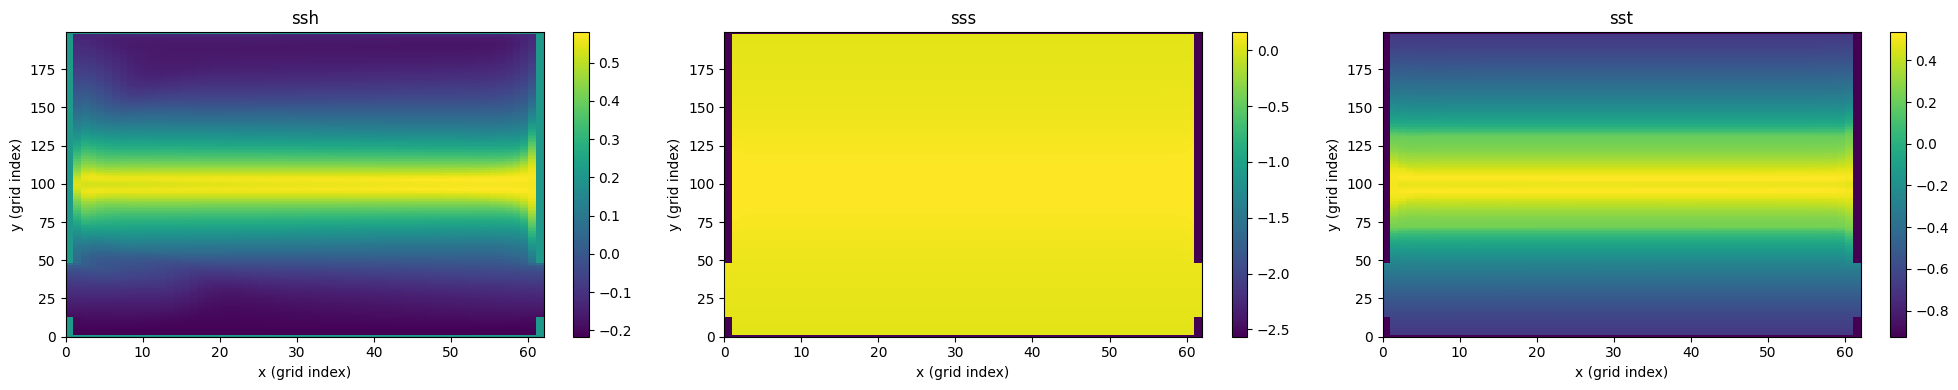

In [46]:
# Snapshot plots use standardized training data.
# Salinity edge values near -1.75 come from raw 0.0 boundary cells after scaling.
# They are not negative physical salinity.
simus = [sims["ssh"], sims["sss"], sims["sst"]]
# Matching display names for plots.
names = [ssh_term, so_term, thetao_term]
print(
    sims["sss"].simulation[0, 0],
    sims["sss"].simulation.shape,
    sims["sss"].simulation[0, 0].shape,
)
plot_simulation_snapshots(simus, names);

In [47]:
# To inspect the ocean interior values instead of the boundary mask:
ocean_interior = sims["sss"].simulation[0]
print("Min ocean value (excl. boundary):", np.min(ocean_interior[ocean_interior > -2.5]))
print("Max ocean value:", np.max(ocean_interior))

Min ocean value (excl. boundary): 0.040838804
Max ocean value: 0.16049251


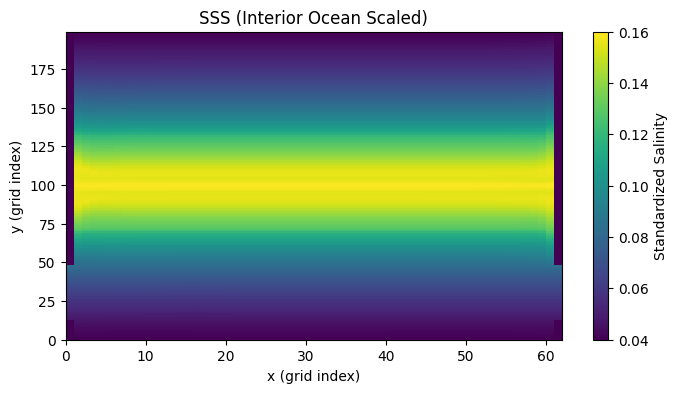

In [48]:
import matplotlib.pyplot as plt

# Extract surface slice
sss_surface = sims["sss"].simulation[0, 0] if sims["sss"].simulation.ndim == 4 else sims["sss"].simulation[0]

fig, ax = plt.subplots(figsize=(8, 4))
# Focus the color scale strictly on the ocean variation (0.04 to 0.16)
im = ax.pcolormesh(sss_surface, vmin=0.04, vmax=0.16)
plt.colorbar(im, ax=ax, label="Standardized Salinity")
ax.set_title("SSS (Interior Ocean Scaled)")
ax.set_xlabel("x (grid index)")
ax.set_ylabel("y (grid index)")
plt.show()

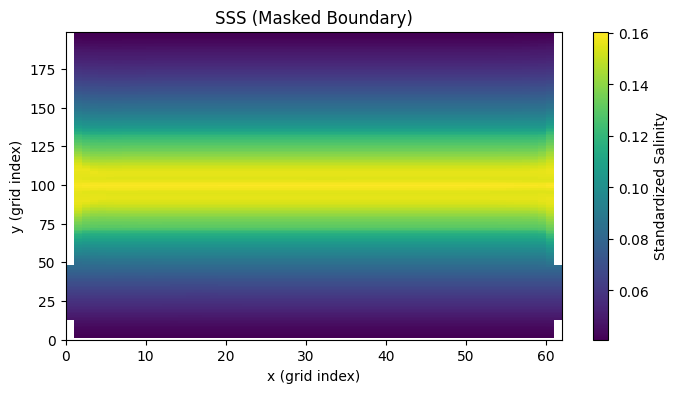

In [49]:
import matplotlib.pyplot as plt
import numpy as np

sss_surface = sims["sss"].simulation[0, 0] if sims["sss"].simulation.ndim == 4 else sims["sss"].simulation[0]

# Mask out land/boundary cells below -2.0 so matplotlib treats them as transparent
sss_masked = np.ma.masked_less(sss_surface, -2.0)

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.pcolormesh(sss_masked)
plt.colorbar(im, ax=ax, label="Standardized Salinity")
ax.set_title("SSS (Masked Boundary)")
ax.set_xlabel("x (grid index)")
ax.set_ylabel("y (grid index)")
plt.show()

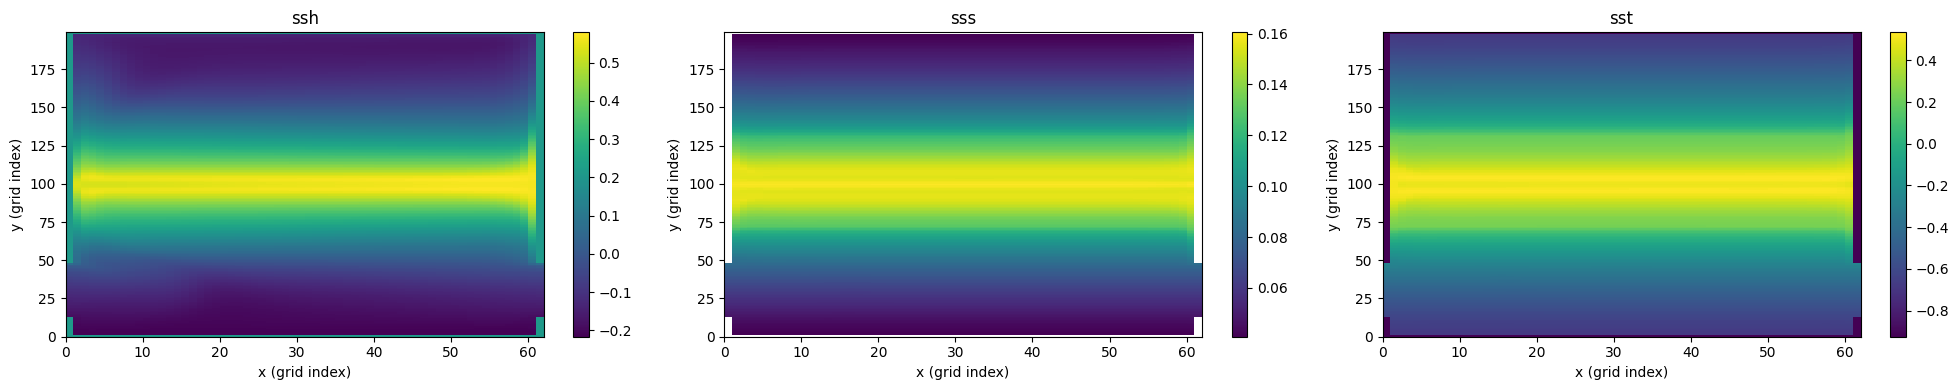

(<Figure size 2000x400 with 6 Axes>,
 array([<Axes: title={'center': 'ssh'}, xlabel='x (grid index)', ylabel='y (grid index)'>,
        <Axes: title={'center': 'sss'}, xlabel='x (grid index)', ylabel='y (grid index)'>,
        <Axes: title={'center': 'sst'}, xlabel='x (grid index)', ylabel='y (grid index)'>],
       dtype=object))

In [50]:
import numpy as np

# Mask out boundary/land cells (< -2.0) across all simulations
for key in sims:
    sims[key].simulation = np.ma.masked_less(sims[key].simulation, -2.0)

# Now plot using the helper function
plot_simulation_snapshots(simus, names)

## 2) PCA decomposition and diagnostics


- `decompose_all(sims)` applies dimensionality reduction for each term.
- `compute_rmse_for_terms(...)` computes reconstruction RMSE with all fitted components.
- `rmseVs["zos"]` has shape `(time,)`: one RMSE value per SSH field and time step.
- `rmseVs["so"]` and `rmseVs["thetao"]` have shape `(time, depth)`: one RMSE value per
  depth slice and time step.
- `rmseMs["zos"]` has shape `(lat, lon)`: RMSE at each SSH grid point over time.
- `rmseMs["so"]` and `rmseMs["thetao"]` have shape `(depth, lat, lon)`: the map plot
  averages error over depth.
- `make_dicos(sims)` builds the saved `*.npz` and `pca_*` outputs.


In [80]:
import torch
import numpy as np

for spec in TERM_SPECS:
    sim = sims[spec.key]
    dr = sim.dimensionality_reduction
    
    # 1. Attach simulation shape metadata to the wrapper
    dr.set_from_simulation(sim)
    
    # 2. Point to the file prefix: .../simu_prepared/ssh/ssh
    term_prefix = weights_base / spec.term / spec.term
    
    # 3. Load weights
    dr.load_weights(str(term_prefix))
    
    # 4. Direct encoding pass (bypasses training loop)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data_tensor = torch.tensor(sim.simulation, dtype=torch.float32)
    if data_tensor.dim() == 3:  # Add channel dim for 2D fields (N, H, W) -> (N, 1, H, W)
        data_tensor = data_tensor.unsqueeze(1)
        
    batch_size = 64
    latents = []
    
    dr.model.eval()
    with torch.no_grad():
        for i in range(0, len(data_tensor), batch_size):
            batch = data_tensor[i : i + batch_size].to(device)
            # forward() returns: reconstructed, mu, logvar
            _, mu, _ = dr.model(batch)
            latents.append(mu.cpu().numpy())
            
    # Store latent components
    sim.components = np.concatenate(latents, axis=0)
    dr.components = sim.components
    
    # 5. Attach land/ocean boolean mask to the simulation object for make_dico()
    if hasattr(dr, "bool_mask") and dr.bool_mask is not None:
        sim.bool_mask = dr.bool_mask
    else:
        # Generate boolean mask directly from finite ocean grid values
        sim.bool_mask = np.isfinite(sim.simulation[0])
        dr.bool_mask = sim.bool_mask
        
    print(f"Loaded & Encoded {spec.term}. Components shape: {sim.components.shape}")

# 6. Build simulation dictionaries cleanly
dicos = {k: s.make_dico() for k, s in sims.items()}

[CVAE] Network weights successfully reloaded from: C:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\2026-07-15_22-52-04.093130Z_3eae7915\forecast\simu_prepared\ssh\ssh_vae_weights.pt
Loaded & Encoded ssh. Components shape: (2400, 10)
[CVAE] Network weights successfully reloaded from: C:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\2026-07-15_22-52-04.093130Z_3eae7915\forecast\simu_prepared\sss\sss_vae_weights.pt
Loaded & Encoded sss. Components shape: (2400, 10)
[CVAE] Network weights successfully reloaded from: C:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\2026-07-15_22-52-04.093130Z_3eae7915\forecast\simu_prepared\sst\sst_vae_weights.pt
Loaded & Encoded sst. Components shape: (2400, 10)


In [86]:
recs, rmseVs, rmseMs = compute_rmse_for_terms(
    TERM_SPECS, sims, n_components=comp_value
)

RMSE computed for ssh
RMSE computed for sss
RMSE computed for sst


In [87]:
import numpy as np

print("=" * 45)
print(f"{'TERM':<10} | {'TIME MEAN RMSE':<18} | {'SPATIAL MEAN RMSE':<18}")
print("=" * 45)

for key in rmseVs:
    # Handle scalar vs array outputs
    val_v = np.mean(rmseVs[key]) if hasattr(rmseVs[key], "__len__") else rmseVs[key]
    val_m = np.nanmean(rmseMs[key]) if hasattr(rmseMs[key], "__len__") else rmseMs[key]
    
    print(f"{key.upper():<10} | {val_v:<18.6f} | {val_m:<18.6f}")

print("=" * 45)

TERM       | TIME MEAN RMSE     | SPATIAL MEAN RMSE 
SSH        | 0.120736           | 0.090909          
SSS        | 0.117883           | 0.043600          
SST        | 2.265498           | 0.671876          


In [88]:
import importlib
import nemo_spinup_forecast.dimensionality_reduction as dim_red
import nemo_spinup_forecast.pipeline_utils as pipeline_utils

# Force Python to reload the updated code from disk
importlib.reload(dim_red)
importlib.reload(pipeline_utils)

# Re-import the updated compute function
from nemo_spinup_forecast.pipeline_utils import compute_rmse_for_terms

In [66]:
import pandas as pd
import numpy as np

summary_data = []

for key in rmseVs:
    v_rmse = rmseVs[key]
    m_rmse = rmseMs[key]
    
    summary_data.append({
        "Variable": key.upper(),
        "Mean RMSE (Time)": np.mean(v_rmse) if hasattr(v_rmse, "__len__") else v_rmse,
        "Min RMSE (Time)": np.min(v_rmse) if hasattr(v_rmse, "__len__") else v_rmse,
        "Max RMSE (Time)": np.max(v_rmse) if hasattr(v_rmse, "__len__") else v_rmse,
        "Spatial Mean RMSE": np.nanmean(m_rmse) if hasattr(m_rmse, "__len__") else m_rmse,
    })

df_rmse = pd.DataFrame(summary_data)
display(df_rmse)

,Variable,Mean RMSE (Time),Min RMSE (Time),Max RMSE (Time),Spatial Mean RMSE
0,SSH,0.396755,0.352492,0.694364,0.316508
1,SSS,35.137161,35.136706,35.140028,35.788328
2,SST,17.254938,17.244581,17.451250,15.506174


In [68]:
# Quick check for SSS scale mismatch
sss_sim = sims["sss"]
dr_sss = sss_sim.dimensionality_reduction

# Reconstruct components
rec = dr_sss.reconstruct_components(n=comp_value)

print("Truth Mean (Raw):", np.nanmean(sss_sim.simulation))
print("Reconstruction Mean:", np.nanmean(rec))
print("Stored Standardization Metadata (desc):", dr_sss.desc)

Truth Mean (Raw): 0.09667025
Reconstruction Mean: 0.047850695
Stored Standardization Metadata (desc): {'mean': np.float32(34.574783), 'std': np.float32(6.7380323), 'min': np.float32(0.0), 'max': np.float32(36.91495)}


In [69]:
import numpy as np

for key, spec in zip(sims, TERM_SPECS):
    sim = sims[key]
    dr = sim.dimensionality_reduction
    desc = sim.desc
    
    # 1. Standardized reconstructed components
    rec_std = dr.reconstruct_components(n=comp_value)
    truth_std = sim.simulation
    
    # Standardized RMSE
    rmse_std = np.sqrt(np.nanmean((truth_std - rec_std) ** 2))
    
    # 2. Raw physical scale (un-standardizing BOTH arrays)
    if desc and "std" in desc:
        rec_raw = rec_std * 2 * desc["std"] + desc["mean"]
        truth_raw = truth_std * 2 * desc["std"] + desc["mean"]
        rmse_physical = np.sqrt(np.nanmean((truth_raw - rec_raw) ** 2))
    else:
        rmse_physical = rmse_std

    unit = "m" if key == "ssh" else ("PSU" if key == "sss" else "°C")
    print(f"[{key.upper()}] Standardized RMSE: {rmse_std:.4f} | Physical RMSE: {rmse_physical:.4f} {unit}")

[SSH] Standardized RMSE: 0.0929 | Physical RMSE: 0.1354 m
[SSS] Standardized RMSE: 0.0090 | Physical RMSE: 0.1207 PSU
[SST] Standardized RMSE: 0.1374 | Physical RMSE: 2.2668 °C


In [67]:
for key in rmseVs:
    print(f"[{key.upper()}]")
    print(f"  • rmseVs shape: {np.shape(rmseVs[key])}")
    print(f"  • rmseMs shape: {np.shape(rmseMs[key])}")

[SSH]
  • rmseVs shape: (2400,)
  • rmseMs shape: (199, 62)
[SSS]
  • rmseVs shape: (2400,)
  • rmseMs shape: (199, 62)
[SST]
  • rmseVs shape: (2400,)
  • rmseMs shape: (199, 62)


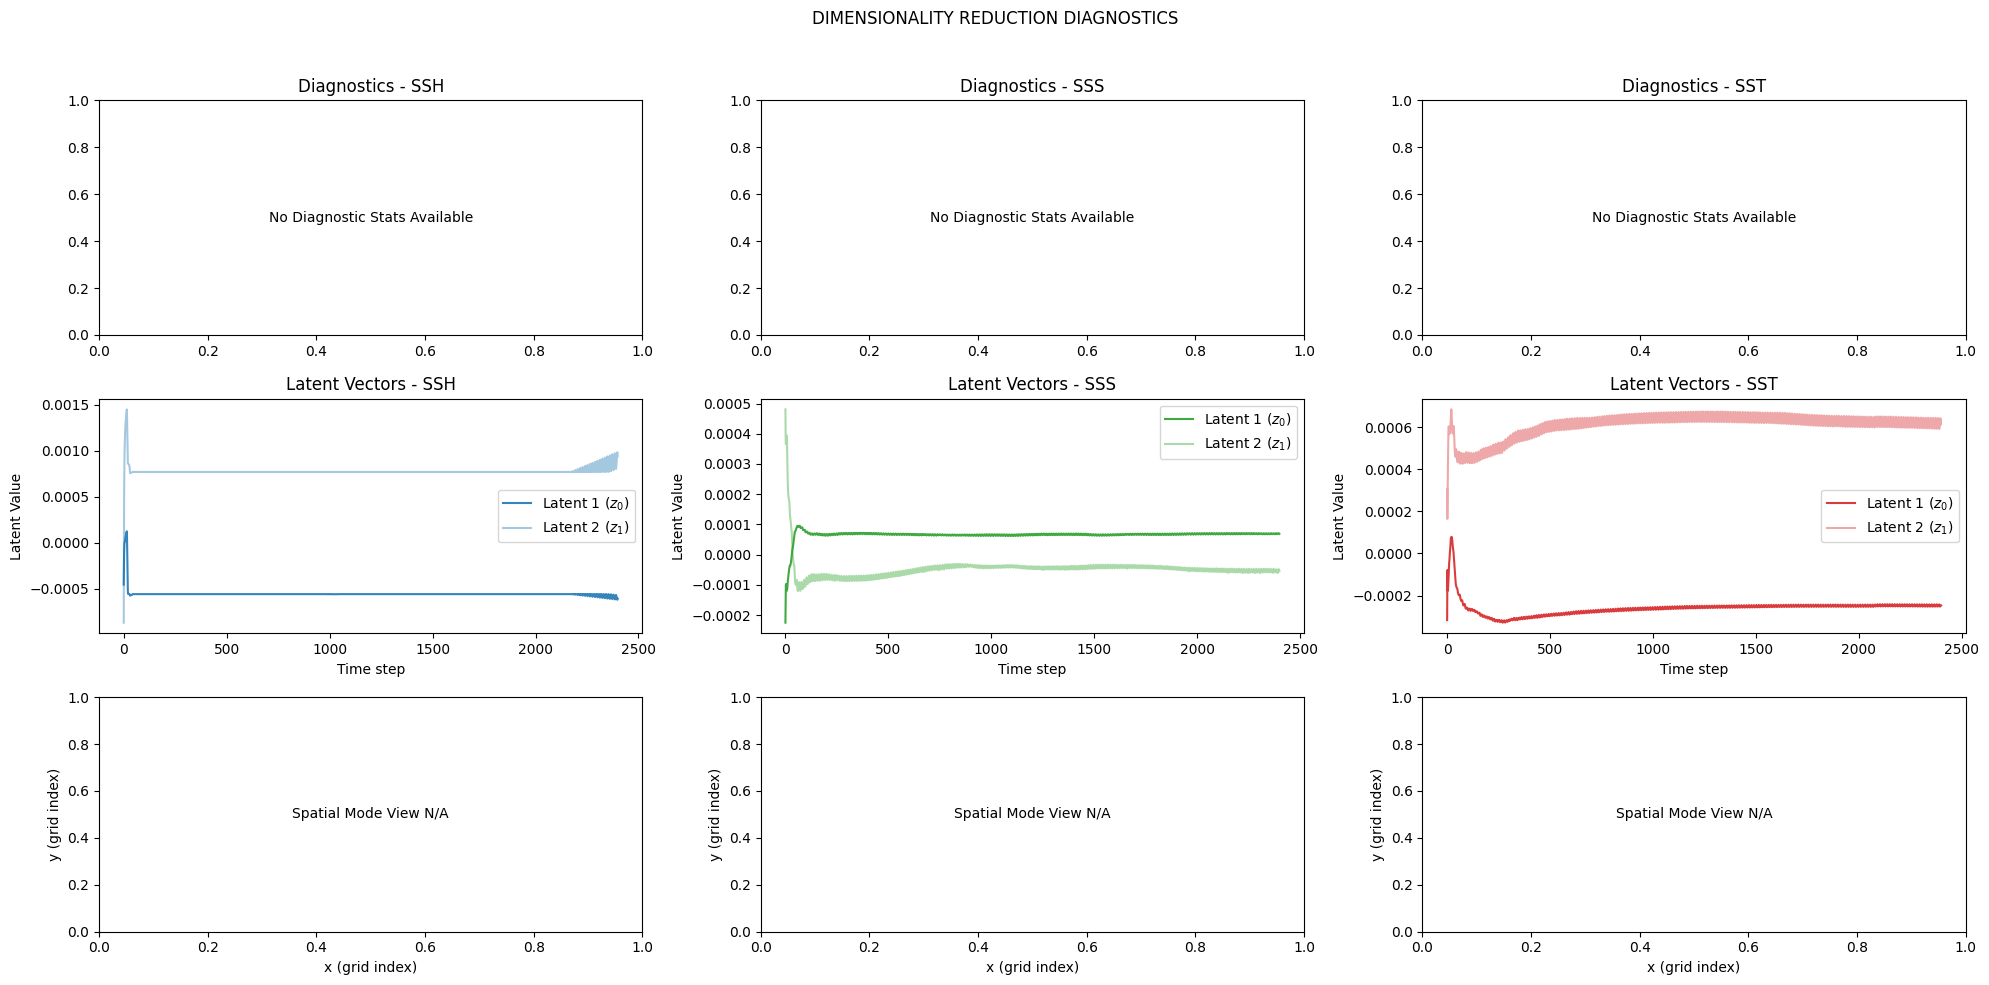

In [89]:
from nemo_spinup_forecast.plotting_utils_cvae import plot_dr_diagnostics

# 1. Prepare inputs matching the function parameters
simus = [sims[spec.key] for spec in TERM_SPECS]
names = [spec.key.upper() for spec in TERM_SPECS]
colors = ["tab:blue", "tab:green", "tab:red"]

# 2. Call CVAE-compatible diagnostics plot
fig, axes = plot_dr_diagnostics(simus, names, colors)

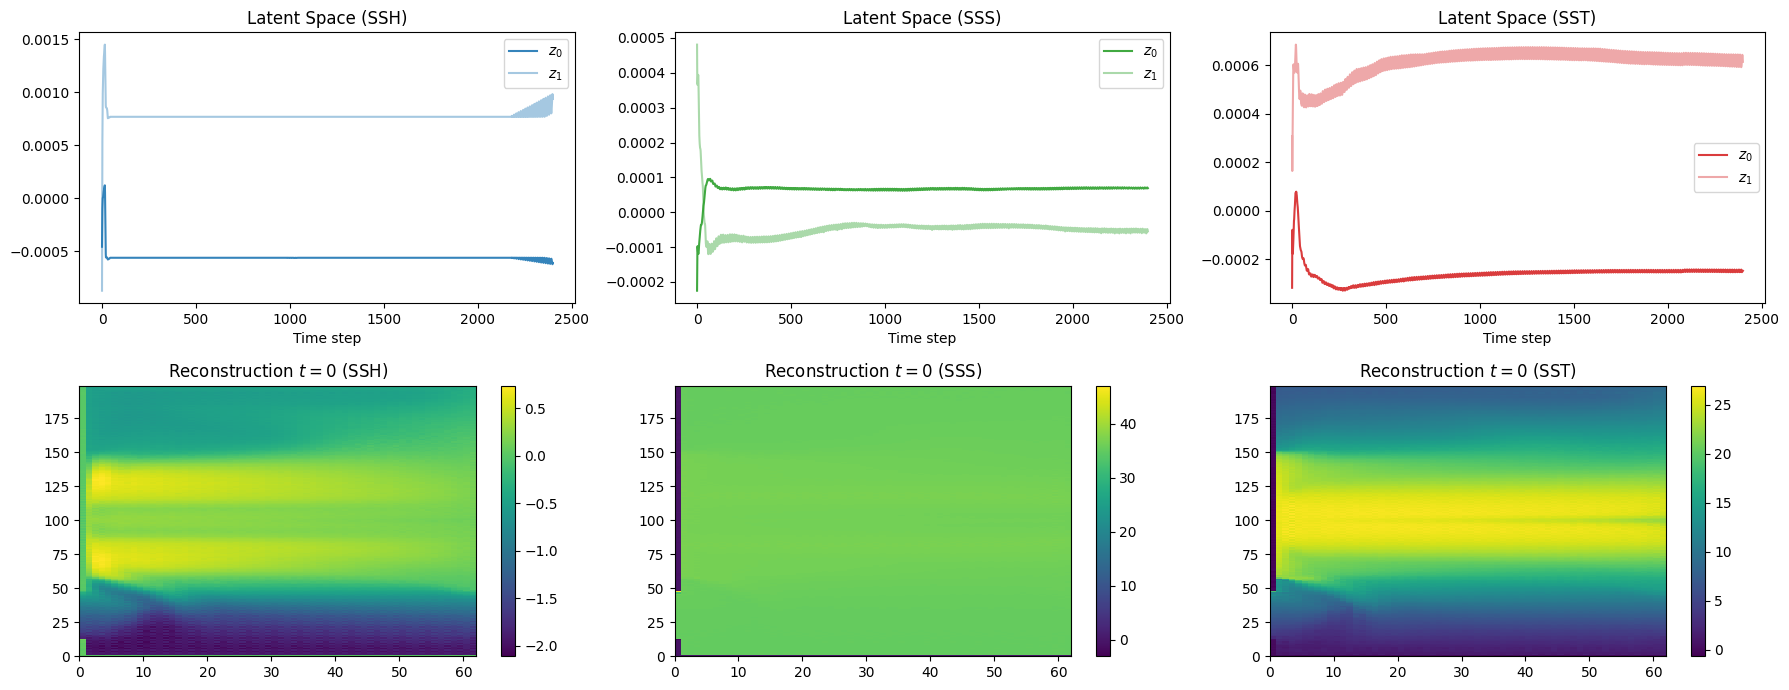

In [90]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, len(sims), figsize=(18, 7))

for i, spec in enumerate(TERM_SPECS):
    key = spec.key
    sim = sims[key]
    dr = sim.dimensionality_reduction
    color = ["tab:blue", "tab:green", "tab:red"][i]
    
    # 1. Latent Trajectories
    latents = getattr(sim, "components", getattr(sim, "latents", None))
    if latents is not None:
        axes[0, i].plot(latents[:, 0], color=color, alpha=0.9, label="$z_0$")
        if latents.shape[1] > 1:
            axes[0, i].plot(latents[:, 1], color=color, alpha=0.4, label="$z_1$")
        axes[0, i].set_title(f"Latent Space ({key.upper()})")
        axes[0, i].set_xlabel("Time step")
        axes[0, i].legend()

    # 2. Reconstructed Spatial Map (First Time Step)
    rec_phys = recs[key][0]  # First frame from your computed physical reconstructions
    if rec_phys.ndim == 3:
        rec_phys = rec_phys[0]  # Surface layer if 3D
        
    im = axes[1, i].pcolormesh(rec_phys, cmap="viridis")
    plt.colorbar(im, ax=axes[1, i])
    axes[1, i].set_title(f"Reconstruction $t=0$ ({key.upper()})")

plt.tight_layout()
plt.show()

In [18]:
import xarray as xr

# Load simulation data to get total depth levels
array = xr.open_dataset(
    sims["sss"].files[-1], decode_times=False, chunks={"time": 200, "x": 120}
)

In [ ]:
maps = [rmseMs["zos"], rmseMs["so"], rmseMs["thetao"]]
names = [ssh_term, so_term, thetao_term]
colors = ["tab:blue", "darkgreen", "darkred"]
# Only 4D variables (so, thetao) have a depth axis; SSH is excluded.
plot_rmse_depth_profile(
    [rmseVs["so"].T, rmseVs["thetao"].T],
    array.deptht,
    [so_term, thetao_term],
    ["darkgreen", "darkred"],
    "PCA reconstruction RMSE by depth",
);

In [ ]:
import xarray as xr

# Load simulation dataset to access depth coordinates
ds = xr.open_dataset(
    sims["sss"].files[-1], decode_times=False, chunks={"time": 200, "x": 120}
)

# Set spatial map inputs
maps = [rmseMs["zos"], rmseMs["so"], rmseMs["thetao"]]
names = [ssh_term, so_term, thetao_term]
colors = ["tab:blue", "darkgreen", "darkred"]

# Plot RMSE vs Depth for 3D ocean variables (so, thetao)
plot_rmse_depth_profile(
    [rmseVs["so"].T, rmseVs["thetao"].T],
    ds.deptht,
    [so_term, thetao_term],
    ["darkgreen", "darkred"],
    "CVAE Reconstruction RMSE by Depth",
)

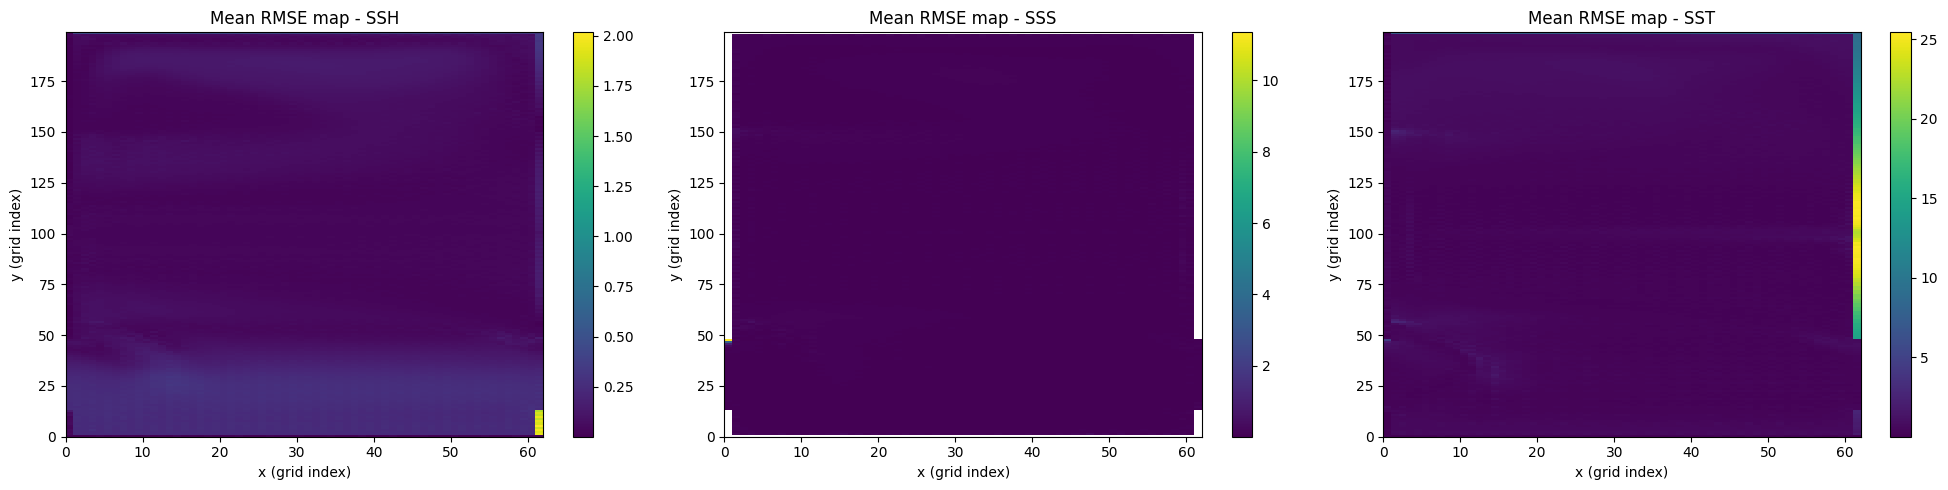

(<Figure size 2000x500 with 6 Axes>,
 array([<Axes: title={'center': 'Mean RMSE map - SSH'}, xlabel='x (grid index)', ylabel='y (grid index)'>,
        <Axes: title={'center': 'Mean RMSE map - SSS'}, xlabel='x (grid index)', ylabel='y (grid index)'>,
        <Axes: title={'center': 'Mean RMSE map - SST'}, xlabel='x (grid index)', ylabel='y (grid index)'>],
       dtype=object))

In [96]:
from nemo_spinup_forecast.plotting_utils_cvae import plot_rmse_maps

# Select spatial RMSE maps for your surface variables
maps = [rmseMs["ssh"], rmseMs["sss"], rmseMs["sst"]]
names = ["SSH", "SSS", "SST"]

# Plot spatial distribution of mean RMSE
plot_rmse_maps(maps, names)

In [95]:
print("Available coordinates:", list(ds.coords.keys()))

Available coordinates: ['nav_lat', 'nav_lon', 'time_centered', 'time_counter']


In [97]:
import xarray as xr

# Path to your 3D grid_T file
file_path = r"C:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\2026-07-15_22-52-04.093130Z_3eae7915\forecast\DINO_1m_grid_T.nc"

# Open the 3D dataset
ds_3d = xr.open_dataset(file_path, decode_times=False)

print("=== Coordinates ===")
for coord_name in ds_3d.coords:
    print(f" - {coord_name}: shape {ds_3d[coord_name].shape}")

print("\n=== 3D Data Variables ===")
for var_name, var in ds_3d.data_vars.items():
    print(f" - {var_name}: dims {var.dims}, shape {var.shape}")

=== Coordinates ===
 - nav_lat: shape (199, 62)
 - nav_lon: shape (199, 62)
 - time_centered: shape (2400,)
 - time_counter: shape (2400,)

=== 3D Data Variables ===
 - time_centered_bounds: dims ('time_counter', 'axis_nbounds'), shape (2400, 2)
 - time_counter_bounds: dims ('time_counter', 'axis_nbounds'), shape (2400, 2)
 - ssh: dims ('time_counter', 'y', 'x'), shape (2400, 199, 62)
 - sst: dims ('time_counter', 'y', 'x'), shape (2400, 199, 62)
 - sss: dims ('time_counter', 'y', 'x'), shape (2400, 199, 62)
 - saltflx: dims ('time_counter', 'y', 'x'), shape (2400, 199, 62)
 - qns: dims ('time_counter', 'y', 'x'), shape (2400, 199, 62)
 - qsr: dims ('time_counter', 'y', 'x'), shape (2400, 199, 62)
 - mldr10_1: dims ('time_counter', 'y', 'x'), shape (2400, 199, 62)
 - mldr10_1max: dims ('time_counter', 'y', 'x'), shape (2400, 199, 62)


In [109]:
import os
import numpy as np
import xarray as xr
from pathlib import Path

# Import your CVAE wrapper class directly
from nemo_spinup_forecast.dimensionality_reduction import DimensionalityReductionCVAE

# ==========================================
# 1. SETUP PATHS
# ==========================================
run_dir = Path(
    r"C:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\2026-07-15_22-52-04.093130Z_3eae7915\forecast"
)
ref_nc_path = run_dir / "DINO_1m_grid_T.nc"
prepared_dir = run_dir / "simu_prepared"
output_dir = run_dir / "simu_predicted"

output_dir.mkdir(parents=True, exist_ok=True)

# Load reference dataset coordinates
ref_ds = xr.open_dataset(ref_nc_path, decode_times=False)
terms = ["ssh", "sss", "sst"]
data_vars = {}

print("=" * 65)
print("DECODING 2,400 TIMESTEPS USING DimensionalityReductionCVAE")
print("=" * 65)

for term in terms:
    print(f"\nProcessing [{term.upper()}]...")
    
    term_dir = prepared_dir / term
    npz_path = term_dir / f"{term}.npz"
    prefix_path = str(term_dir / term)
    
    if not npz_path.exists():
        print(f"  Warning: Missing file at {npz_path}. Skipping.")
        continue

    # 1. Load npz metadata archive
    npz_data = np.load(npz_path, allow_pickle=True)
    latents = npz_data["ts"]                             # Shape: (2400, 10)
    mask = npz_data["mask"]                               # Shape: (199, 62)
    desc = npz_data["desc"].item() if "desc" in npz_data else None

    print(f"  ├── Loaded Latents Shape : {latents.shape}")
    print(f"  ├── Land/Ocean Mask Shape: {mask.shape}")

    # 2. Instantiate CVAE Wrapper
    dr = DimensionalityReductionCVAE(comp=10)
    dr.bool_mask = mask
    dr.shape = (1, *mask.shape[-2:]) if mask.ndim == 2 else mask.shape
    dr.desc = desc

    # 3. Reload PyTorch Network Weights
    dr.load_weights(prefix_path)

    # 4. Decode full 2,400 timeline & apply un-standardization scale
    _, reconstructed = dr.reconstruct_predictions(
        predictions=latents,
        n=10,
        info={"mask": mask, "desc": desc}
    )

    print(f"  ├── Reconstructed Shape  : {reconstructed.shape}")
    print(f"  └── Range (Min / Max)    : {np.nanmin(reconstructed):.4f} / {np.nanmax(reconstructed):.4f}")

    # Save array to predicted directory
    npy_save_path = output_dir / f"{term}.npy"
    np.save(npy_save_path, reconstructed)
    
    # Store for NetCDF creation
    data_vars[term] = (("time_counter", "y", "x"), reconstructed)

# ==========================================
# 2. EXPORT TO NETCDF
# ==========================================
out_nc_ds = xr.Dataset(
    data_vars=data_vars,
    coords=ref_ds.coords,
    attrs=ref_ds.attrs
)

output_nc_file = output_dir / "grid_T_2D.nc"
out_nc_ds.to_netcdf(output_nc_file)

print("\n" + "=" * 65)
print(f"SUCCESS! Created 2,400-timestep NetCDF dataset:")
print(f"Path: {output_nc_file}")
print("=" * 65)

DECODING 2,400 TIMESTEPS USING DimensionalityReductionCVAE

Processing [SSH]...
  ├── Loaded Latents Shape : (2400, 10)
  ├── Land/Ocean Mask Shape: (199, 62)
Using Convolutional VAE (Latent components: 10, Beta: 0.01)
[CVAE] Network weights successfully reloaded from: C:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\2026-07-15_22-52-04.093130Z_3eae7915\forecast\simu_prepared\ssh\ssh_vae_weights.pt
  ├── Reconstructed Shape  : (2400, 199, 62)
  └── Range (Min / Max)    : -2.1082 / 0.7375

Processing [SSS]...
  ├── Loaded Latents Shape : (2400, 10)
  ├── Land/Ocean Mask Shape: (199, 62)
Using Convolutional VAE (Latent components: 10, Beta: 0.01)
[CVAE] Network weights successfully reloaded from: C:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\2026-07-15_22-52-04.093130Z_3eae7915\forecast\simu_prepared\sss\sss_vae_weights.pt
  ├── Reconstructed Shape  : (2400, 199, 62)
  └── Range (Min / Max)    : -3.0383 / 47.0197

Processing [SST]...
  ├── Loade

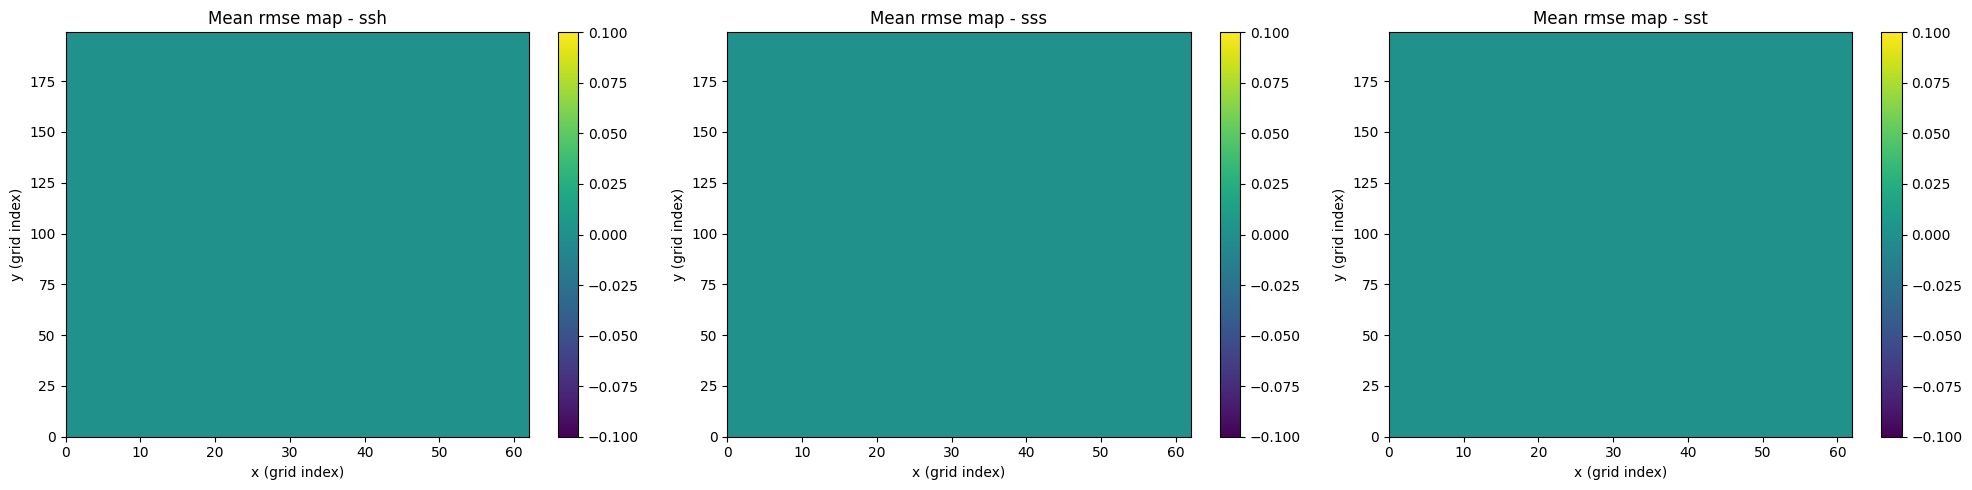

(<Figure size 2000x500 with 6 Axes>,
 array([<Axes: title={'center': 'Mean rmse map - ssh'}, xlabel='x (grid index)', ylabel='y (grid index)'>,
        <Axes: title={'center': 'Mean rmse map - sss'}, xlabel='x (grid index)', ylabel='y (grid index)'>,
        <Axes: title={'center': 'Mean rmse map - sst'}, xlabel='x (grid index)', ylabel='y (grid index)'>],
       dtype=object))

In [31]:
maps = [rmseMs["ssh"], rmseMs["sss"], rmseMs["sst"]]
names = [ssh_term, so_term, thetao_term]

plot_rmse_maps(maps, names)

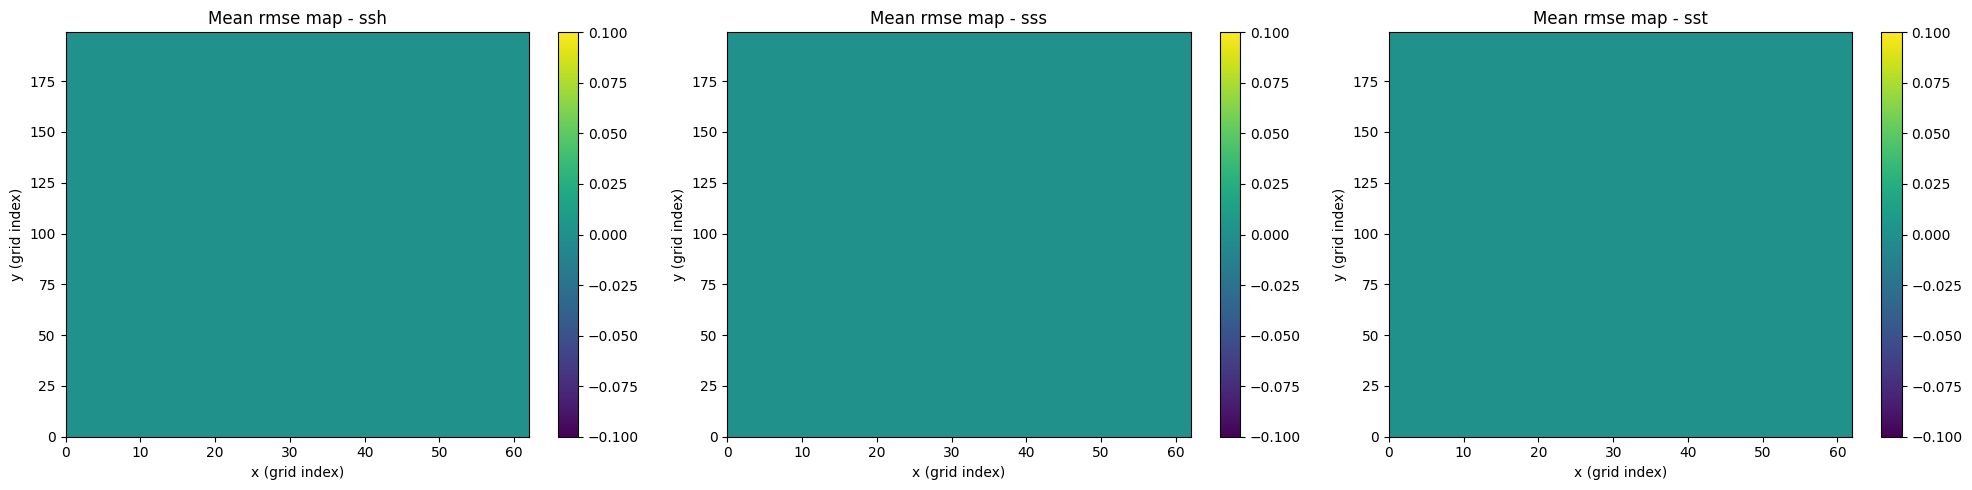

In [32]:
# SSH is plotted directly as a 2D RMSE map.
# Salinity and temperature RMSE maps are averaged over depth first.
plot_rmse_maps(maps, names);

In [ ]:
dicos = make_dicos(sims)

In [ ]:
for spec in TERM_SPECS:
    term_dir = prepared_dir / spec.term
    term_dir.mkdir(parents=True, exist_ok=True)
    
    # Retrieve CVAE object (checks .dimensionality_reduction or .cvae attribute)
    dr_obj = getattr(sims[spec.key], "dimensionality_reduction", getattr(sims[spec.key], "cvae", None))
    
    # 1. Save CVAE configuration and metadata via Pickle
    with open(term_dir / f"cvae_{spec.term}", "wb") as file:
        pickle.dump(dr_obj, file)
        
    # 2. Save PyTorch network weights (.pt file)
    if dr_obj is not None:
        dr_obj.save_weights(str(term_dir / spec.term))
        
    # 3. Save numerical dictionary arrays
    np.savez(term_dir / spec.term, **dicos[spec.key])

In [103]:
import pickle
import numpy as np
from nemo_spinup_forecast.dimensionality_reduction import DimensionalityReductionCVAE

for spec in TERM_SPECS:
    term_dir = prepared_dir / spec.term
    term_dir.mkdir(parents=True, exist_ok=True)
    
    # Retrieve CVAE object
    dr_obj = getattr(sims[spec.key], "dimensionality_reduction", getattr(sims[spec.key], "cvae", None))
    
    if dr_obj is not None:
        # 1. Re-bind the class identity to fix Jupyter's module reload mismatch
        dr_obj.__class__ = DimensionalityReductionCVAE
        
        # 2. Save PyTorch network weights (.pt file) FIRST
        dr_obj.save_weights(str(term_dir / spec.term))
        
        # 3. Save metadata configuration via Pickle
        with open(term_dir / f"pca_{spec.term}", "wb") as file:
            pickle.dump(dr_obj, file)
            
    # 4. Save numerical dictionary arrays
    np.savez(term_dir / spec.term, **dicos[spec.key])

[CVAE] Model weights successfully written to: C:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\2026-07-15_22-52-04.093130Z_3eae7915\forecast\runs\2026-07-21_18-19-16.574890Z_86e7ab21\simu_prepared\ssh\ssh_vae_weights.pt
[CVAE] Model weights successfully written to: C:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\2026-07-15_22-52-04.093130Z_3eae7915\forecast\runs\2026-07-21_18-19-16.574890Z_86e7ab21\simu_prepared\sss\sss_vae_weights.pt
[CVAE] Model weights successfully written to: C:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\2026-07-15_22-52-04.093130Z_3eae7915\forecast\runs\2026-07-21_18-19-16.574890Z_86e7ab21\simu_prepared\sst\sst_vae_weights.pt


In [107]:
import os
import numpy as np
from pathlib import Path

# Path to the simu_prepared folder from your log
prepared_dir = Path(
    r"C:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\2026-07-15_22-52-04.093130Z_3eae7915\forecast\simu_prepared"
)

print("=" * 65)
print(f"INSPECTING PREPARED (.npz) FILES IN: {prepared_dir}")
print("=" * 65)

if not prepared_dir.exists():
    print(f"Error: Path does not exist: {prepared_dir}")
    exit(1)

# Search recursively for all .npz files in simu_prepared
npz_files = list(prepared_dir.glob("**/*.npz"))

if not npz_files:
    print("No .npz files found in simu_prepared.")
else:
    for npz_path in npz_files:
        rel_path = npz_path.relative_to(prepared_dir)
        print(f"\n📁 Archive: {rel_path}")
        print("-" * 50)
        
        try:
            # Load the .npz archive
            with np.load(npz_path) as data:
                keys = data.files
                print(f"  Internal Keys found: {keys}")
                
                for key in keys:
                    arr = data[key]
                    print(f"  ├── Key '{key}':")
                    print(f"  │    ├── Shape   : {arr.shape}")
                    print(f"  │    ├── Dtype   : {arr.dtype}")
                    if np.issubdtype(arr.dtype, np.number):
                        print(f"  │    ├── Min/Max : {np.nanmin(arr):.4f} / {np.nanmax(arr):.4f}")
                        print(f"  │    └── Has NaNs: {np.isnan(arr).any()}")
        except Exception as e:
            print(f"  Error reading {npz_path}: {e}")

print("\n" + "=" * 65)

INSPECTING PREPARED (.npz) FILES IN: C:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\2026-07-15_22-52-04.093130Z_3eae7915\forecast\simu_prepared

📁 Archive: ssh\ssh.npz
--------------------------------------------------
  Internal Keys found: ['ts', 'mask', 'desc', 'cut', 'x_size', 'y_size', 'shape']
  ├── Key 'ts':
  │    ├── Shape   : (2400, 10)
  │    ├── Dtype   : float64
  │    ├── Min/Max : -0.0155 / 0.0099
  │    └── Has NaNs: False
  ├── Key 'mask':
  │    ├── Shape   : (199, 62)
  │    ├── Dtype   : bool
  Error reading C:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\2026-07-15_22-52-04.093130Z_3eae7915\forecast\simu_prepared\ssh\ssh.npz: Object arrays cannot be loaded when allow_pickle=False

📁 Archive: sss\sss.npz
--------------------------------------------------
  Internal Keys found: ['ts', 'mask', 'desc', 'cut', 'x_size', 'y_size', 'shape']
  ├── Key 'ts':
  │    ├── Shape   : (2400, 10)
  │    ├── Dtype   : float64
  │    ├── Mi

## 3) Forecast in component space


- `load_ts_all(prepared_path, TERM_SPECS)` loads prepared component time series.
- `build_predictions(...)` creates one `Predictions` object per term.
- `Predictions.forecast_single_series(...)` is used as a single-component demo.
- No notebook seed is set here. The default GP regressor already uses a fixed
  `random_state=42`.
- `forecast_all(...)` returns raw forecast component tables keyed by term.
- The notebook prepends the training window before reconstruction.
- `Simulation.reconstruct(...)` maps predicted components back to physical space.

In [101]:
prepared_dir.mkdir(parents=True, exist_ok=True)

for spec in TERM_SPECS:
    term_dir = prepared_dir / spec.term
    term_dir.mkdir(parents=True, exist_ok=True)

    # Make sure the directory exists
    print(f"Preparing {term_dir}")

    # Save the same artifact structure expected by load_ts_all(...)
    # If make_dicos(...) works for your CVAE run, use it.
    try:
        dicos = make_dicos(sims)
        np.savez(term_dir / spec.term, **dicos[spec.key])
    except Exception as e:
        print(f"make_dicos failed for {spec.key}: {e}")

        # Fallback: save the raw transformed components if available
        data = getattr(sims[spec.key], "components_", None)
        if data is None:
            data = getattr(sims[spec.key], "transformed_data", None)
        if data is None:
            data = getattr(sims[spec.key], "simulation", None)

        if data is None:
            raise

        np.savez(term_dir / spec.term, components=np.asarray(data))

Preparing C:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\2026-07-15_22-52-04.093130Z_3eae7915\forecast\runs\2026-07-21_18-19-16.574890Z_86e7ab21\simu_prepared\ssh
ssh to dictionary
sss to dictionary
sst to dictionary
Preparing C:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\2026-07-15_22-52-04.093130Z_3eae7915\forecast\runs\2026-07-21_18-19-16.574890Z_86e7ab21\simu_prepared\sss
ssh to dictionary
sss to dictionary
sst to dictionary
Preparing C:\2025\MSc CS AI\Thesis\NEMO Spin-Up Benchmark\nemo-spinup-forecast\2026-07-15_22-52-04.093130Z_3eae7915\forecast\runs\2026-07-21_18-19-16.574890Z_86e7ab21\simu_prepared\sst
ssh to dictionary
sss to dictionary
sst to dictionary


In [104]:
prepared_path = str(prepared_dir)

# Load one PCA component time-series table and one metadata dict per term.
component_ts_by_term, metadata_by_term = load_ts_all(prepared_path, TERM_SPECS)


preds = build_predictions(
    TERM_SPECS,
    component_ts_by_term,
    metadata_by_term,
    forecast_method,
    dimensionality_reduction_method,
)

Using Convolutional VAE (Latent components: 10, Beta: 0.01)
Using Convolutional VAE (Latent components: 10, Beta: 0.01)
Using Convolutional VAE (Latent components: 10, Beta: 0.01)


In [105]:
comp, train_len = 1, len(preds["ssh"])
colors = {"ssh": None, "sss": "darkgreen", "sst": "darkred"}

# Single-component forecast for component `comp`.
single_forecast_by_term, single_forecast_std_by_term, single_forecast_metrics_by_term = (
    {},
    {},
    {},
)
for spec in TERM_SPECS:
    hat, std, metrics = preds[spec.key].forecast_single_series(comp, train_len, steps)
    single_forecast_by_term[spec.key] = hat
    single_forecast_std_by_term[spec.key] = std
    single_forecast_metrics_by_term[spec.key] = metrics

print("single_forecast_zos shape:", single_forecast_by_term["zos"].shape)

# Reuse Predictions.show for quick visual inspection.
for spec in TERM_SPECS:
    c = colors[spec.key]
    if c is None:
        preds[spec.key].show(
            comp,
            single_forecast_by_term[spec.key],
            single_forecast_std_by_term[spec.key],
            train_len,
        )
    else:
        preds[spec.key].show(
            comp,
            single_forecast_by_term[spec.key],
            single_forecast_std_by_term[spec.key],
            train_len,
            color=c,
        )

KeyboardInterrupt: 

In [ ]:
(
    forecast_component_ts_by_term,
    forecast_component_std_by_term,
    forecast_metrics_by_term,
) = forecast_all(TERM_SPECS, preds, train_len=train_len, steps=steps)
# `forecast_all(...)` returns forecast rows only.
# Prepend the training window before reconstruction.
forecast_component_ts_by_term = {
    k: pd.concat([component_ts_by_term[k][:train_len], h])
    for k, h in forecast_component_ts_by_term.items()
}

In [ ]:
# Reconstruct physical-space fields from predicted component series.
predictions = {}
for spec in TERM_SPECS:
    n = np.shape(preds[spec.key].info["ts"])[1]
    predictions[spec.key] = sims[spec.key].reconstruct(
        forecast_component_ts_by_term[spec.key], n, preds[spec.key].info
    )
    print(f"{spec.key} reconstructed with all comp")

In [ ]:
maps = [predictions["zos"], predictions["so"], predictions["thetao"]]
names = [ssh_term, so_term, thetao_term]

# Plot one reconstructed layer for each ocean field.
plot_reconstructions(maps, names);

## 4) Save reconstructed predictions


In [ ]:
# Save reconstructed predicted fields.
pred_dir.mkdir(exist_ok=True)

# Use the external file term from TERM_SPECS when saving outputs.
for spec in TERM_SPECS:
    np.save(pred_dir / f"pred_{spec.term}.npy", predictions[spec.key])

## 5) Evaluate prediction errors in physical space


In [106]:
# Reload predictions using the same term metadata as the save step.
pred_arrays = {
    spec.key: np.load(pred_dir / f"pred_{spec.term}.npy") for spec in TERM_SPECS
}

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\2025\\MSc CS AI\\Thesis\\NEMO Spin-Up Benchmark\\nemo-spinup-forecast\\2026-07-15_22-52-04.093130Z_3eae7915\\forecast\\runs\\2026-07-21_18-19-16.574890Z_86e7ab21\\simu_predicted\\pred_ssh.npy'

In [ ]:
id_, start2, end2 = "106", start, end + steps  # start, end + steps
ye = True
# Build reference simulations over training + forecast window.
ref = build_simulations(
    TERM_SPECS,
    data_path=data_path,
    start=start2,
    end=end2,
    comp=comp_value,
    ye=ye,
    dr_method=dimensionality_reduction_method,
    # Keep reference arrays on original scale for direct comparison.
    stand=False,
)

In [ ]:
# Load simulation data to read depth levels for profile plots.
array = xr.open_dataset(
    ref["so"].files[-1], decode_times=False, chunks={"time": 200, "x": 120}
)
depth = array.deptht
del array

### Absolute error summary (forecast vs pre-forecast)

`abs_error_stats(...)` splits each error array into two windows:
- `pred_*`: the last `steps` samples, i.e. the forecast window.
- `ref_*`: the earlier training window.

SSH is reduced to one mean absolute error per window.
Salinity and temperature keep depth, so the profiles show mean absolute error by depth.

The last plots compare mean predicted and reference profiles.


In [36]:
# Absolute errors between reconstructed predictions and references.
# pred_arrays are loaded in the previous cell.
print(ref)
errs = {k: np.abs(ref[k].simulation - pred_arrays[k]) for k in pred_arrays}

print("pred_zos shape:", pred_arrays["ssh"].shape)
print("ref_zos shape:", ref["ssh"].simulation.shape)
# Split errors into forecast window and pre-forecast baseline window.
error_stats = {}
for spec in TERM_SPECS:
    error_stats[spec.key] = abs_error_stats(
        errs[spec.key],
        steps=steps,
        axes=spec.err_axes,
    )

# Display summary of aggregated error-statistic shapes.
summary_rows = []
for spec in TERM_SPECS:
    s = error_stats[spec.key]
    summary_rows.append(
        {
            "term": spec.key,
            "pred_mean_shape": np.shape(s["pred_mean"]),
            "ref_mean_shape": np.shape(s["ref_mean"]),
        }
    )
pd.DataFrame(summary_rows)

NameError: name 'ref' is not defined

In [ ]:
categories = ["Forecast", "Pre-forecast"]

# Plot SSH mean absolute error with standard-deviation bars.
means = [error_stats["zos"]["pred_mean"], error_stats["zos"]["ref_mean"]]
print(means)
errors = [error_stats["zos"]["pred_std"], error_stats["zos"]["ref_std"]]

plot_bar_with_errors(
    categories,
    means,
    errors,
    "Mean Error with Standard Error",
    "Error",
);

In [ ]:
# Plot depth-wise mean absolute errors for temperature and salinity.
plot_depth_error_profiles(
    depth,
    [error_stats["thetao"]["ref_mean"], error_stats["so"]["ref_mean"]],
    [error_stats["thetao"]["ref_std"], error_stats["so"]["ref_std"]],
    [error_stats["thetao"]["pred_mean"], error_stats["so"]["pred_mean"]],
    [error_stats["thetao"]["pred_std"], error_stats["so"]["pred_std"]],
    ["thetao", "so"],
    ["darkred", "darkgreen"],
    f"Absolute error on {steps} last predictions",
);

In [ ]:
# Mean profiles using axes declared in TERM_SPECS.
# so/thetao: mean over (time, lat, lon) -> depth profile.
# zos: mean over (lat, lon) -> time series.


mean_pred, mean_ref = {}, {}
for spec in TERM_SPECS:
    mean_pred[spec.key] = np.nanmean(pred_arrays[spec.key], axis=spec.mean_axes)
    mean_ref[spec.key] = np.nanmean(ref[spec.key].simulation, axis=spec.mean_axes)

print({k: v.shape for k, v in mean_pred.items()})
print({k: v.shape for k, v in mean_ref.items()})

In [ ]:
print("depth shape: ", depth.shape)
print("mean_pred_so shape: ", mean_pred["so"].shape)

# Compare mean predicted and reference profiles.
plot_depth_prediction_reference(
    depth,
    [mean_pred["so"], mean_pred["thetao"]],
    [mean_ref["so"], mean_ref["thetao"]],
    ["Salinity", "Temperature"],
);

## 6) Compare forecasted component time series with separately fitted PCA reference component

The forecasted component series come from the original training PCA fit.
The grey reference lines come from a fresh PCA fit on the longer reference window.
These plots can be used as a qualitative view, not as a direct component-by-component check.


In [ ]:
# Normalize the longer reference window and do a PCA decomposition.

for spec in TERM_SPECS:
    normalise_time_series(ref[spec.key])


decompose_all(ref)

In [ ]:
simus = [ref["zos"], ref["so"], ref["thetao"]]
names = [ssh_term, so_term, thetao_term]
colors = ["tab:blue", "tab:green", "tab:red"]

plot_pca_diagnostics(simus, names, colors);

In [ ]:
comp = 0
ref_list = [ref["zos"], ref["so"], ref["thetao"]]
pred = [
    forecast_component_ts_by_term["zos"],
    forecast_component_ts_by_term["so"],
    forecast_component_ts_by_term["thetao"],
]
names = [ssh_term, so_term, thetao_term]
colors = ["tab:blue", "tab:green", "tab:red"]
total_len = len(ref_list[0].simulation)

plot_component_timeseries(ref_list, pred, names, colors, comp, total_len, train_len);

In [ ]:
comp = 1

plot_component_timeseries(ref_list, pred, names, colors, comp, total_len, train_len);

In [ ]:
comp = 2

plot_component_timeseries(ref_list, pred, names, colors, comp, total_len, train_len);